# Analyse the natural groups in the data

I'm going to  run t-SNE vidualisation over session_data_full.csv

In [10]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA

from sklearn.preprocessing import StandardScaler
import seaborn as sns



import os
import core.constants as c
from core.utils import save_df_as_table_image

session_data_full = pd.read_csv(c.RICKD_SESSION_DATA_FULL_CLEANED_FILE)
session_data_full

,id,sub_id,datestring,filename,speed_r,age,Height,Weight,Gender,DominantLeg,...,injury2_code,injury_desc,injury2_desc,injury_name,injury2_name,injured_joint_code,injured_joint2_code,injured_side_code,injured_side2_code,has_no_injury
0,100433_20101005t132240,100433,2010-10-05 13:22:40,20101005t132240.json,1.610861,53.0,NaN,NaN,NaN,NaN,...,no_injury,General sensation of discomfort without speci...,No injury has been diagnosed.,pain,no injury,knee,no_injury,right,right,False
1,100434_20101117t132240,100434,2010-11-17 13:22:40,20101117t132240.json,2.237294,51.0,NaN,NaN,female,NaN,...,no_injury,Breakdown and gradual loss of spinal disc cush...,No injury has been diagnosed.,disc degeneration,no injury,lumbar_spine,no_injury,bilateral,right,False
2,100537_20120703t102550,100537,2012-07-03 10:25:50,20120703t102550.json,2.127441,NaN,173.1,67.6,female,right,...,no_injury,General sensation of discomfort without speci...,No injury has been diagnosed.,pain,no injury,hip_pelvis,no_injury,right,right,False
3,100560_20120717t103748,100560,2012-07-17 10:37:48,20120717t103748.json,2.657365,33.0,179.3,83.0,female,right,...,no_injury,No injury has been diagnosed.,No injury has been diagnosed.,no injury,no injury,no_injury,no_injury,right,right,True
4,101481_20120717t105021,101481,2012-07-17 10:50:21,20120717t105021.json,2.625088,32.0,176.3,58.6,female,NaN,...,no_injury,No injury has been diagnosed.,No injury has been diagnosed.,no injury,no injury,no_injury,no_injury,no_injury,no_injury,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1827,200986_20150312t143944,200986,2015-03-12 14:39:44,20150312t143944.json,4.876998,20.0,174.0,56.8,female,right,...,no_injury,No injury has been diagnosed.,No injury has been diagnosed.,no injury,no injury,no_injury,no_injury,no_injury,no_injury,True
1828,200987_20150312t160840,200987,2015-03-12 16:08:40,20150312t160840.json,2.765022,50.0,164.0,60.0,female,right,...,itb_synd,Misalignment or imbalance of pelvic bones caus...,Painful friction of iliotibial band rubbing ov...,pelvic malalignment,itb syndrome,hip_pelvis,thigh,right,left,False
1829,201100_20150409t155915,201100,2015-04-09 15:59:15,20150409t155915.json,2.790966,52.0,170.0,80.0,male,right,...,liga_spra,Muscle fibers stretched or torn due to excessi...,Stretching or tearing of ligaments due to exce...,muscle strain,ligament sprain,lumbar_spine,ankle,bilateral,right,False
1830,201101_20150413t143152,201101,2015-04-13 14:31:52,20150413t143152.json,2.828602,21.0,162.0,65.5,male,right,...,no_injury,No injury has been diagnosed.,No injury has been diagnosed.,no injury,no injury,no_injury,no_injury,no_injury,no_injury,True


In [11]:
# Create is_injured variable as the inverse of has_no_injury
session_data_full['is_injured'] = (~session_data_full["has_no_injury"]).astype(int)

# Split predictor and dependant variables
identifier_cols = [
    "id",
    "sub_id",
    "datestring",
    "filename"
]
dependant_variable_columns = [
    "injury_severity_code",
    "injury_severity_value",
    "injury_code",
    "injury2_code",
    "injury_desc",
    "injury2_desc",
    "injury_name",
    "injury2_name",
    "injured_joint_code",
    "injured_joint2_code",
    "injured_side_code",
    "injured_side2_code",
    "is_injured"
]
# Note, commented out column have been removed because they are not clean and
# do not add value in this state (i.e. RaceTime needs to be combined into a coefficient of performance)
predictor_columns = [
    "speed_r",
    "age",
    "Height",
    "Weight",
    "Gender",
    "DominantLeg",
    # "Activities",
    "Level",
    "YrsRunning",
    # "RaceDistance",
    # "RaceTimeHrs",
    # "RaceTimeMins",
    # "RaceTimeSecs",
    # "YrPR",
    "NumRaces",
    "l_step_width",
    "l_stride_rate",  # Es la inversa del length
    "l_stride_length", # Es comparado con la altura? -> Normalizar contra altura
    "l_swing_time",
    "l_stance_time",
    "l_pelvis_peak_drop_angle",
    "l_pelvis_drop_excursion",
    "l_ankle_df_peak_angle",
    "l_ankle_eve_peak_angle",
    "l_ankle_eve_percent_stance",
    "l_ankle_eve_excursion",
    "l_ankle_rot_peak_angle",
    "l_ankle_rot_excursion",
    "l_knee_flex_peak_angle",
    "l_knee_add_peak_angle",
    "l_knee_add_excursion",
    "l_knee_abd_peak_angle",
    "l_knee_abd_excursion",
    "l_knee_rot_peak_angle",
    "l_knee_rot_excursion",
    "l_hip_ext_peak_angle",
    "l_hip_add_peak_angle",
    "l_hip_add_excursion",
    "l_hip_rot_peak_angle",
    "l_hip_rot_excursion",
    "l_foot_prog_angle",
    "l_foot_ang_at_hs",
    "l_mhw_exc_from_to",
    "l_ankle_eve_peak_vel",
    "l_ankle_rot_peak_vel",
    "l_knee_abd_peak_vel",
    "l_knee_add_peak_vel",
    "l_hip_abd_peak_vel",
    "l_knee_rot_peak_vel",
    "l_hip_rot_peak_vel",
    "l_pronation_onset",
    "l_pronation_offset",
    "l_peak_hip_add_velocity",
    "l_peak_pelvic_drop_velocity",
    "l_vertical_oscillation",
    "r_step_width",
    "r_stride_rate",
    "r_stride_length",
    "r_swing_time",
    "r_stance_time",
    "r_pelvis_peak_drop_angle",
    "r_pelvis_drop_excursion",
    "r_ankle_df_peak_angle",
    "r_ankle_eve_peak_angle",
    "r_ankle_eve_percent_stance",
    "r_ankle_eve_excursion",
    "r_ankle_rot_peak_angle",
    "r_ankle_rot_excursion",
    "r_knee_flex_peak_angle",
    "r_knee_add_peak_angle",
    "r_knee_add_excursion",
    "r_knee_abd_peak_angle",
    "r_knee_abd_excursion",
    "r_knee_rot_peak_angle",
    "r_knee_rot_excursion",
    "r_hip_ext_peak_angle",
    "r_hip_add_peak_angle",
    "r_hip_add_excursion",
    "r_hip_rot_peak_angle",
    "r_hip_rot_excursion",
    "r_foot_prog_angle",
    "r_foot_ang_at_hs",
    "r_mhw_exc_from_to",
    "r_ankle_eve_peak_vel",
    "r_ankle_rot_peak_vel",
    "r_knee_abd_peak_vel",
    "r_knee_add_peak_vel",
    "r_hip_abd_peak_vel",
    "r_knee_rot_peak_vel",
    "r_hip_rot_peak_vel",
    "r_pronation_onset",
    "r_pronation_offset",
    "r_peak_hip_add_velocity",
    "r_peak_pelvic_drop_velocity",
    "r_vertical_oscillation",
]

Y = session_data_full.set_index("id")[dependant_variable_columns].copy()
X = session_data_full.set_index("id")[predictor_columns].copy()

print("X")
display(X.head())

print("Y")
display(Y.head())


X


,speed_r,age,Height,Weight,Gender,DominantLeg,Level,YrsRunning,NumRaces,l_step_width,...,r_knee_abd_peak_vel,r_knee_add_peak_vel,r_hip_abd_peak_vel,r_knee_rot_peak_vel,r_hip_rot_peak_vel,r_pronation_onset,r_pronation_offset,r_peak_hip_add_velocity,r_peak_pelvic_drop_velocity,r_vertical_oscillation
id,,,,,,,,,,,,,,,,,,,,,
100433_20101005t132240,1.610861,53.0,NaN,NaN,NaN,NaN,recreational,13.0,NaN,0.048521,...,-71.422163,49.606277,-17.620105,121.078813,95.598653,17,57,59.323001,-75.058744,51.466247
100434_20101117t132240,2.237294,51.0,NaN,NaN,female,NaN,recreational,20.0,NaN,-0.002092,...,-54.774824,60.136863,-42.544797,292.718838,17.255165,8,53,183.573751,-96.178927,62.307667
100537_20120703t102550,2.127441,NaN,173.1,67.6,female,right,recreational,2.0,NaN,0.057484,...,-115.248831,48.898541,-55.286282,318.798151,201.561725,13,56,257.430836,-62.804925,81.753809
100560_20120717t103748,2.657365,33.0,179.3,83.0,female,right,recreational,NaN,NaN,0.081206,...,-129.419031,74.009251,-109.157604,349.195418,84.881142,20,55,320.445059,-141.687354,111.686204
101481_20120717t105021,2.625088,32.0,176.3,58.6,female,NaN,NaN,NaN,NaN,0.062199,...,-137.461770,75.703882,-24.314138,226.067684,93.835737,17,57,169.271213,-49.506248,99.045820


Y


,injury_severity_code,injury_severity_value,injury_code,injury2_code,injury_desc,injury2_desc,injury_name,injury2_name,injured_joint_code,injured_joint2_code,injured_side_code,injured_side2_code,is_injured
id,,,,,,,,,,,,,
100433_20101005t132240,volume_intensity,2.0,pain,no_injury,General sensation of discomfort without speci...,No injury has been diagnosed.,pain,no injury,knee,no_injury,right,right,1
100434_20101117t132240,volume_intensity,2.0,disc_dege,no_injury,Breakdown and gradual loss of spinal disc cush...,No injury has been diagnosed.,disc degeneration,no injury,lumbar_spine,no_injury,bilateral,right,1
100537_20120703t102550,missed_2_workouts,3.0,pain,no_injury,General sensation of discomfort without speci...,No injury has been diagnosed.,pain,no injury,hip_pelvis,no_injury,right,right,1
100560_20120717t103748,no_injury,0.0,no_injury,no_injury,No injury has been diagnosed.,No injury has been diagnosed.,no injury,no injury,no_injury,no_injury,right,right,0
101481_20120717t105021,no_injury,0.0,no_injury,no_injury,No injury has been diagnosed.,No injury has been diagnosed.,no injury,no injury,no_injury,no_injury,no_injury,no_injury,0


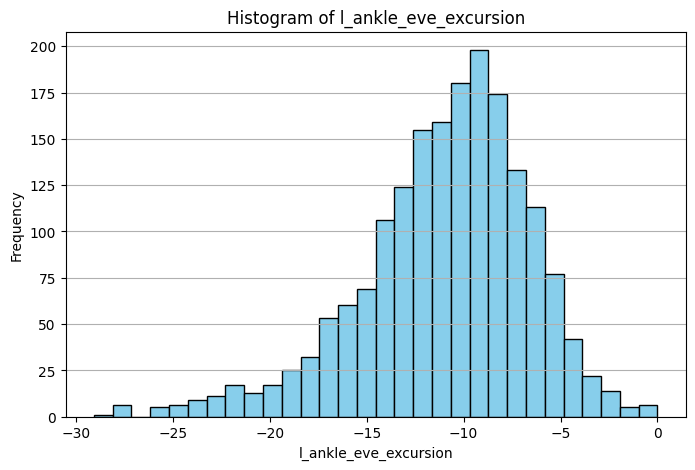

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.hist(X["l_ankle_eve_excursion"].dropna(), bins=30, color='skyblue', edgecolor='black')
plt.title("Histogram of l_ankle_eve_excursion")
plt.xlabel("l_ankle_eve_excursion")
plt.ylabel("Frequency")
plt.grid(axis='y')
plt.show()


In [4]:
# Prepare the dataset for Machine Learning algorithms:
feature_numerical_columns = X.select_dtypes(include=[np.number]).columns.tolist()
feature_categorical_columns = X.select_dtypes(include=['object']).columns.tolist()

if len(X.columns) != (len(feature_numerical_columns) + len(feature_categorical_columns)):
       raise TypeError("You have missed a variable! Check the types")

print("Categorical features:")
print(feature_categorical_columns)
print("Numerical features:")
print(feature_numerical_columns)

Categorical features:
['Gender', 'DominantLeg', 'Level']
Numerical features:
['speed_r', 'age', 'Height', 'Weight', 'YrsRunning', 'NumRaces', 'l_step_width', 'l_stride_rate', 'l_stride_length', 'l_swing_time', 'l_stance_time', 'l_pelvis_peak_drop_angle', 'l_pelvis_drop_excursion', 'l_ankle_df_peak_angle', 'l_ankle_eve_peak_angle', 'l_ankle_eve_percent_stance', 'l_ankle_eve_excursion', 'l_ankle_rot_peak_angle', 'l_ankle_rot_excursion', 'l_knee_flex_peak_angle', 'l_knee_add_peak_angle', 'l_knee_add_excursion', 'l_knee_abd_peak_angle', 'l_knee_abd_excursion', 'l_knee_rot_peak_angle', 'l_knee_rot_excursion', 'l_hip_ext_peak_angle', 'l_hip_add_peak_angle', 'l_hip_add_excursion', 'l_hip_rot_peak_angle', 'l_hip_rot_excursion', 'l_foot_prog_angle', 'l_foot_ang_at_hs', 'l_mhw_exc_from_to', 'l_ankle_eve_peak_vel', 'l_ankle_rot_peak_vel', 'l_knee_abd_peak_vel', 'l_knee_add_peak_vel', 'l_hip_abd_peak_vel', 'l_knee_rot_peak_vel', 'l_hip_rot_peak_vel', 'l_pronation_onset', 'l_pronation_offset', 'l_p

In [5]:
categorical_data = pd.get_dummies(X[feature_categorical_columns].fillna("unknown"))
categorical_data.columns

Index(['Gender_female', 'Gender_male', 'Gender_unknown',
       'DominantLeg_ambidextrous', 'DominantLeg_left', 'DominantLeg_right',
       'DominantLeg_unknown', 'Level_competitive', 'Level_recreational',
       'Level_unknown'],
      dtype='object')

In [25]:
# Create one-hot encoded features for categorical columns
categorical_data = pd.get_dummies(X[feature_categorical_columns].fillna("unknown"))

# We need to remove one category from each group to avoid multicollinearity - We will need to have this into consideration when interpreting the results.
# categorical_data.rename(columns={
#     "Gender_female": "gender_is_female",
#     "Gender_unknown": "gender_is_unknown",
#     "Level_competitive": "level_is_competitive",
#     }, inplace=True)
categorical_data.drop(columns=["Gender_unknown", "DominantLeg_unknown", "Level_unknown"], inplace=True)


# Standardize the numerical features
X_numerical = X[feature_numerical_columns].fillna(0)
scaler = StandardScaler()
X_numerical_scaled = scaler.fit_transform(X_numerical)
X_numerical_scaled_df = pd.DataFrame(X_numerical_scaled, columns=feature_numerical_columns, index=X.index)

# Concatenate standardized numerical and one-hot encoded categorical features
X_combined = pd.concat([X_numerical_scaled_df, categorical_data], axis=1)

print(f"Numerical features: {len(feature_numerical_columns)}")
print(f"Categorical features (after one-hot encoding): {categorical_data.shape[1]}")
print(f"Total features: {X_combined.shape[1]}")
# Display all columns of the dataframe
print("Columns:")
for i, col in enumerate(X_combined.columns, 1):
    print(f"{i:3d}. {col}")
display(X_combined)

Numerical features: 86
Categorical features (after one-hot encoding): 7
Total features: 93
Columns:
  1. speed_r
  2. age
  3. Height
  4. Weight
  5. YrsRunning
  6. NumRaces
  7. l_step_width
  8. l_stride_rate
  9. l_stride_length
 10. l_swing_time
 11. l_stance_time
 12. l_pelvis_peak_drop_angle
 13. l_pelvis_drop_excursion
 14. l_ankle_df_peak_angle
 15. l_ankle_eve_peak_angle
 16. l_ankle_eve_percent_stance
 17. l_ankle_eve_excursion
 18. l_ankle_rot_peak_angle
 19. l_ankle_rot_excursion
 20. l_knee_flex_peak_angle
 21. l_knee_add_peak_angle
 22. l_knee_add_excursion
 23. l_knee_abd_peak_angle
 24. l_knee_abd_excursion
 25. l_knee_rot_peak_angle
 26. l_knee_rot_excursion
 27. l_hip_ext_peak_angle
 28. l_hip_add_peak_angle
 29. l_hip_add_excursion
 30. l_hip_rot_peak_angle
 31. l_hip_rot_excursion
 32. l_foot_prog_angle
 33. l_foot_ang_at_hs
 34. l_mhw_exc_from_to
 35. l_ankle_eve_peak_vel
 36. l_ankle_rot_peak_vel
 37. l_knee_abd_peak_vel
 38. l_knee_add_peak_vel
 39. l_hip_abd_p

,speed_r,age,Height,Weight,YrsRunning,NumRaces,l_step_width,l_stride_rate,l_stride_length,l_swing_time,...,r_peak_hip_add_velocity,r_peak_pelvic_drop_velocity,r_vertical_oscillation,Gender_female,Gender_male,DominantLeg_ambidextrous,DominantLeg_left,DominantLeg_right,Level_competitive,Level_recreational
id,,,,,,,,,,,,,,,,,,,,,
100433_20101005t132240,-2.406926,1.231321,-11.741497,-5.056746,0.578686,-0.393107,-0.307243,0.000986,-2.622528,-0.338913,...,-1.743700,0.239058,-1.935588,False,False,False,False,False,False,True
100434_20101117t132240,-1.095016,1.066816,-11.741497,-5.056746,1.308477,-0.393107,-1.831460,0.886585,-1.458975,-0.466027,...,0.764244,-0.390267,-1.344740,True,False,False,False,False,False,True
100537_20120703t102550,-1.325076,-3.128072,0.097259,-0.179365,-0.568129,-0.393107,-0.037324,-0.643565,-1.241474,-0.084685,...,2.255015,0.604189,-0.284941,True,False,False,False,True,False,True
100560_20120717t103748,-0.215279,-0.413733,0.521293,0.931754,-0.776641,-0.393107,0.677045,-1.610390,0.439240,-1.165155,...,3.526927,-1.746297,1.346349,True,False,False,False,True,False,True
101481_20120717t105021,-0.282875,-0.495986,0.316116,-0.828721,-0.776641,-0.393107,0.104643,-0.746010,-0.016982,-0.148242,...,0.475554,1.000454,0.657459,True,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200986_20150312t143944,4.433200,-1.483018,0.158813,-0.958592,0.057406,-0.393107,0.298318,0.113669,4.753163,0.169543,...,-0.655317,1.410128,-0.130387,True,False,False,False,True,True,False
200987_20150312t160840,0.010181,0.984563,-0.525113,-0.727710,0.891454,-0.124986,0.624754,1.075236,-0.383200,-0.211799,...,0.528663,0.376153,-1.005929,True,False,False,False,True,False,True
201100_20150409t155915,0.064515,1.149068,-0.114758,0.715303,2.351037,-0.393107,1.508322,-1.333275,0.645295,0.805114,...,1.170144,-1.120846,-0.014800,False,True,False,False,True,False,True


In [7]:
X_combined.to_csv(c.RICKD_BASELINE_X_FILE, index=True)
Y.to_csv(c.RICKD_BASELINE_Y_FILE, index=True)

In [8]:
# Apply t-SNE with same values as  5.1 attempt
tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
X_tsne = tsne.fit_transform(X_combined)
tsne.kl_divergence_

/Users/adrianzapaterreig/Documents/Personal/TFM/rickd-analysis/.venv/lib/python3.11/site-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


2.008654832839966

In [9]:
# Grid search for best t-SNE perplexity (minimizing kl_divergence_)
perplexity_values = [5, 10, 20, 30, 40, 50, 60]
kl_divergences = []

print("Grid search for t-SNE perplexity:")
for perplexity in perplexity_values:
    tsne = TSNE(n_components=2, random_state=42, perplexity=perplexity, n_iter=1000)
    X_tsne_tmp = tsne.fit_transform(X_combined)
    kl = tsne.kl_divergence_
    kl_divergences.append(kl)
    print(f"Perplexity: {perplexity:2d} | KL Divergence: {kl:.6f}")

best_idx = int(np.argmin(kl_divergences))
best_perplexity = perplexity_values[best_idx]
best_kl = kl_divergences[best_idx]
print(f"\nBest perplexity: {best_perplexity} (KL Divergence: {best_kl:.6f})")


Grid search for t-SNE perplexity:


/Users/adrianzapaterreig/Documents/Personal/TFM/rickd-analysis/.venv/lib/python3.11/site-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


Perplexity:  5 | KL Divergence: 1.824587


/Users/adrianzapaterreig/Documents/Personal/TFM/rickd-analysis/.venv/lib/python3.11/site-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


Perplexity: 10 | KL Divergence: 2.057612


/Users/adrianzapaterreig/Documents/Personal/TFM/rickd-analysis/.venv/lib/python3.11/site-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


Perplexity: 20 | KL Divergence: 2.065682


/Users/adrianzapaterreig/Documents/Personal/TFM/rickd-analysis/.venv/lib/python3.11/site-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


KeyboardInterrupt: 

In [ ]:
# Apply t-SNE with best perplexity vlaue.
print(f"Running t-SNE with best perplexity value. Value: {best_perplexity}")
tsne = TSNE(n_components=2, random_state=42, perplexity=best_perplexity, n_iter=1000)
X_tsne = tsne.fit_transform(X_combined)
tsne.kl_divergence_

Running t-SNE with best perplexity value. Value: 5


/Users/adrianzapaterreig/Documents/Personal/TFM/rickd-analysis/.venv/lib/python3.11/site-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


1.8245872259140015

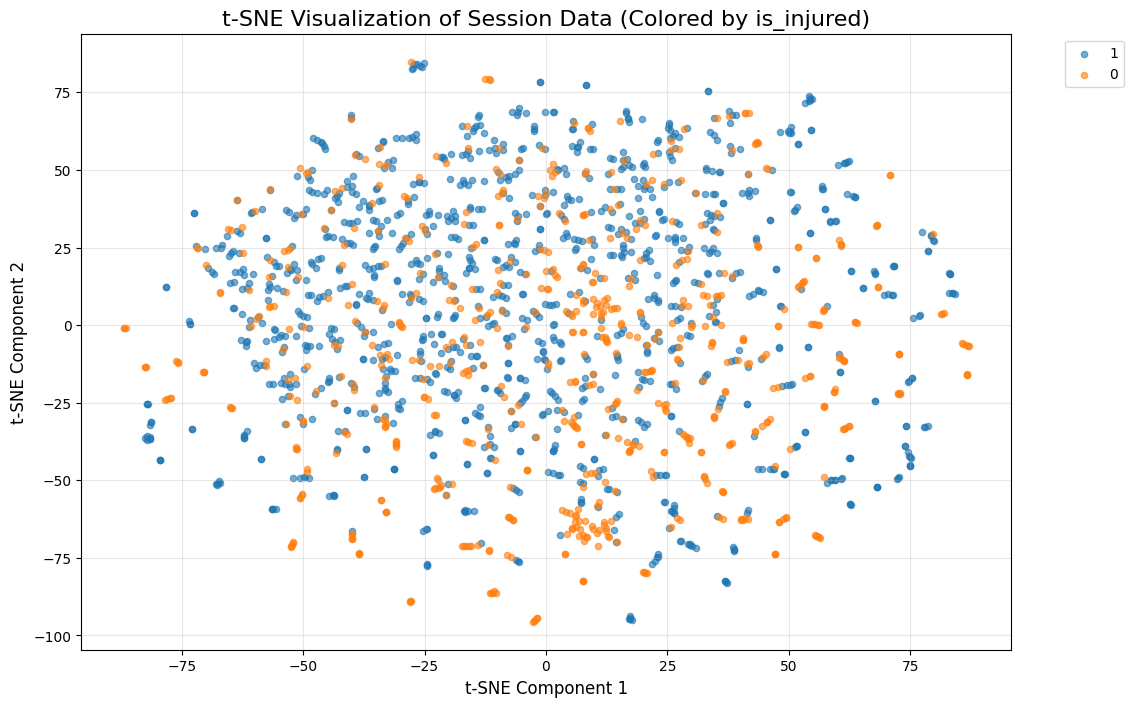

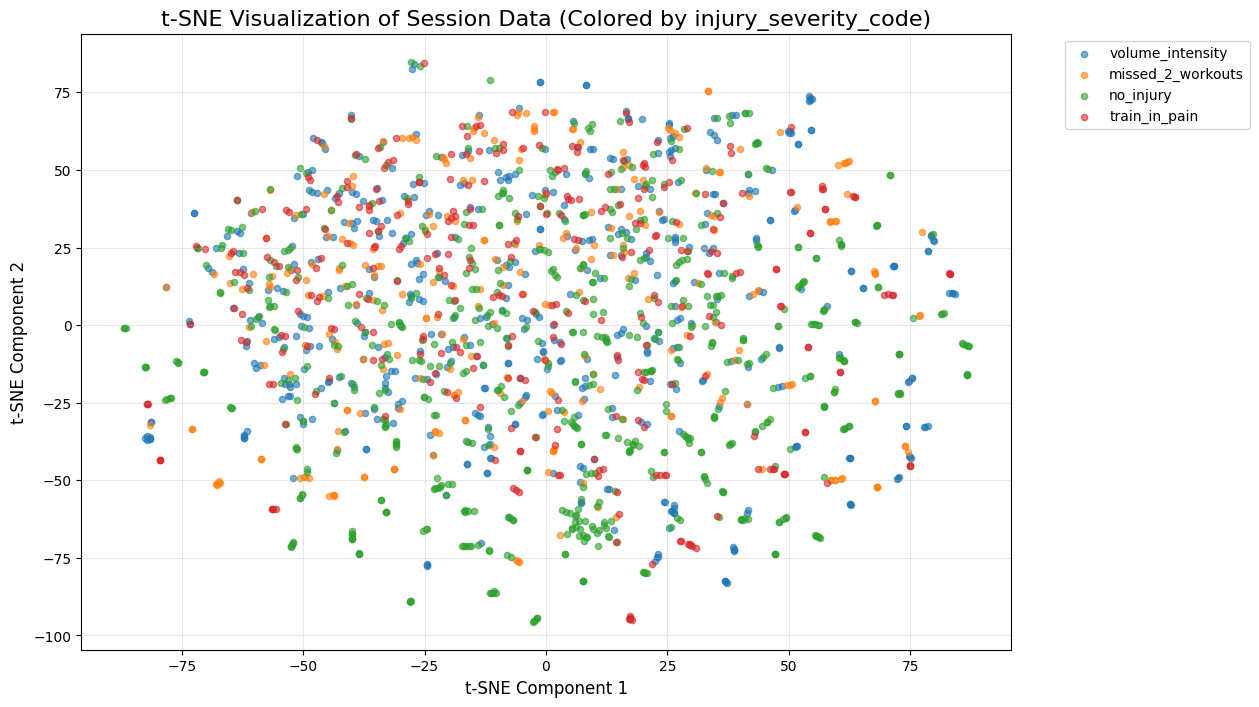

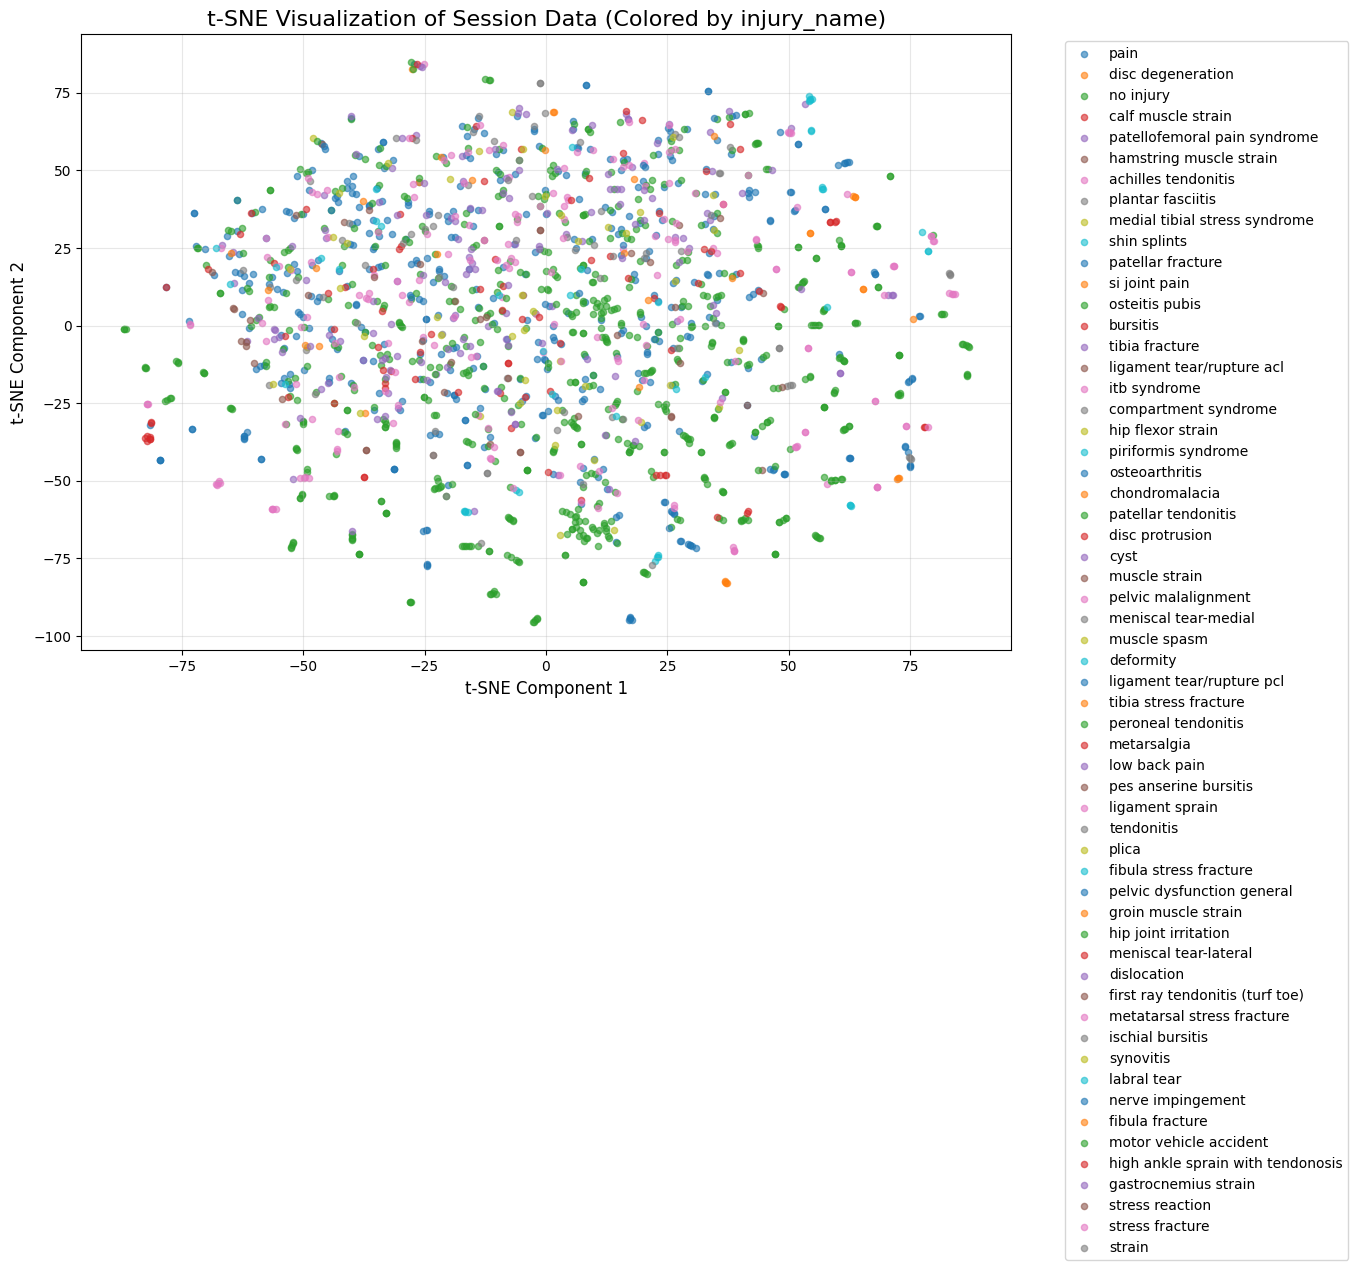

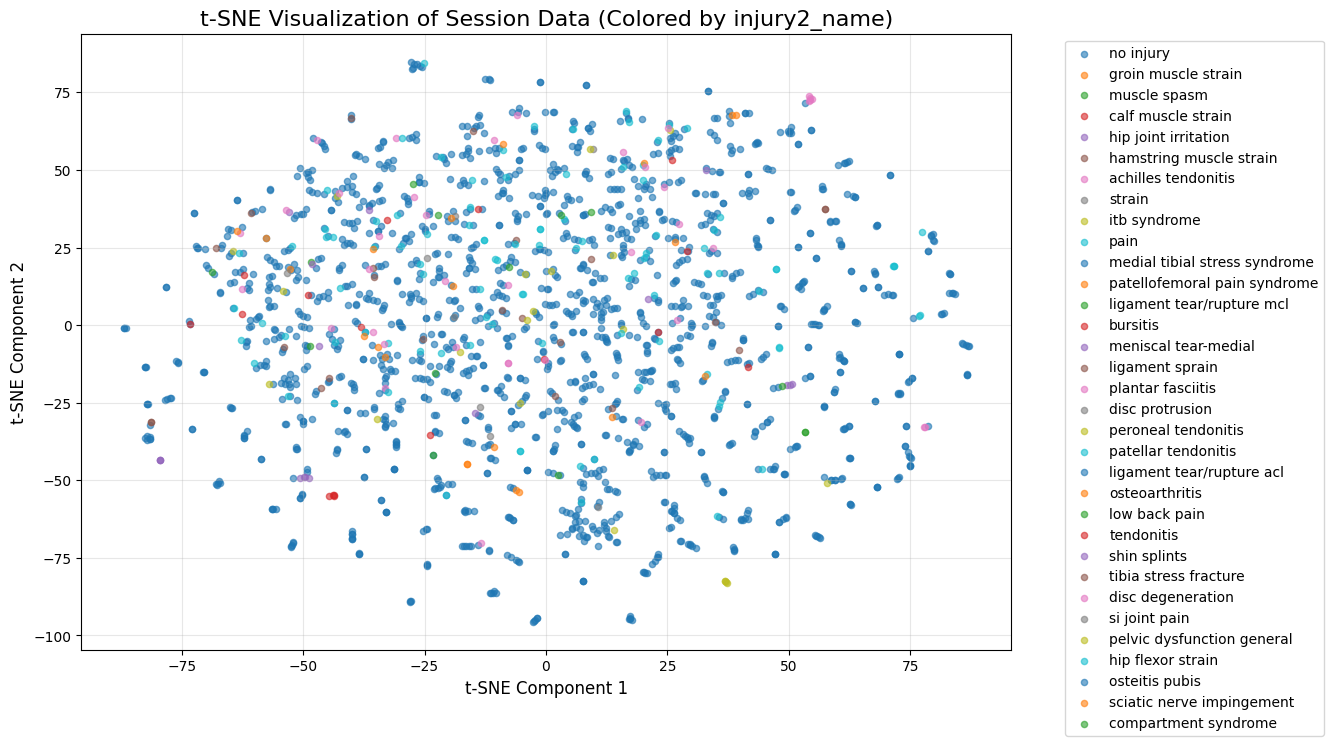

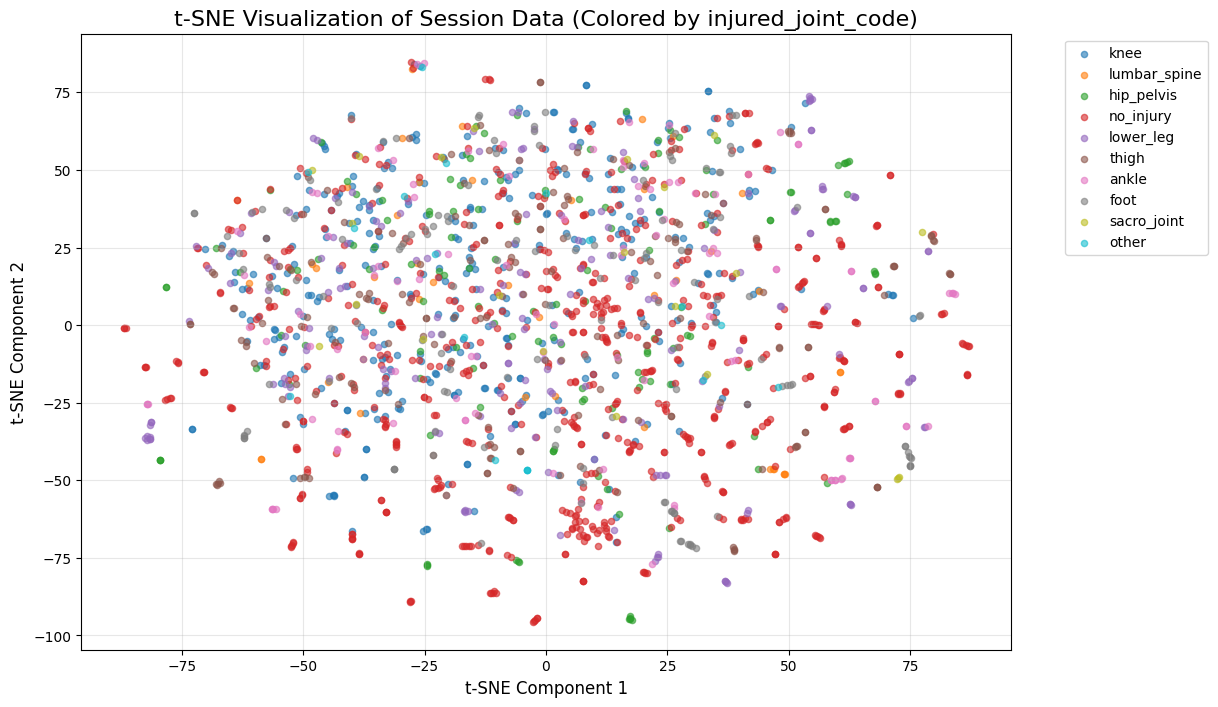

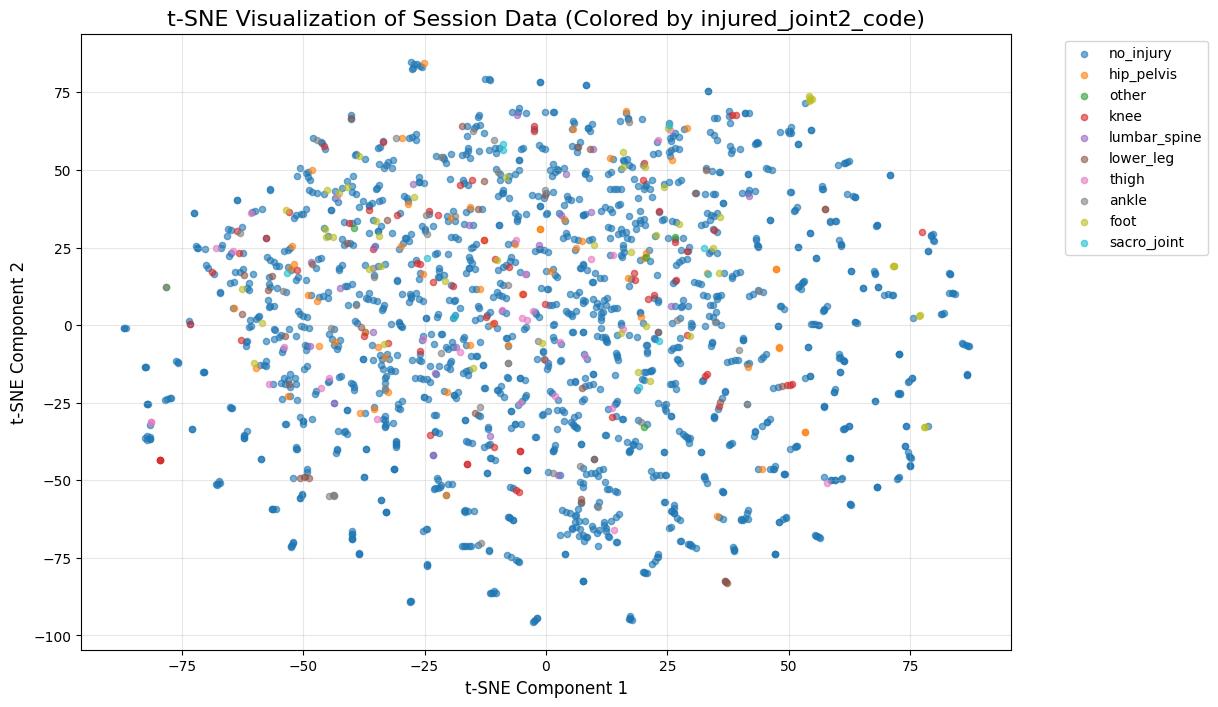

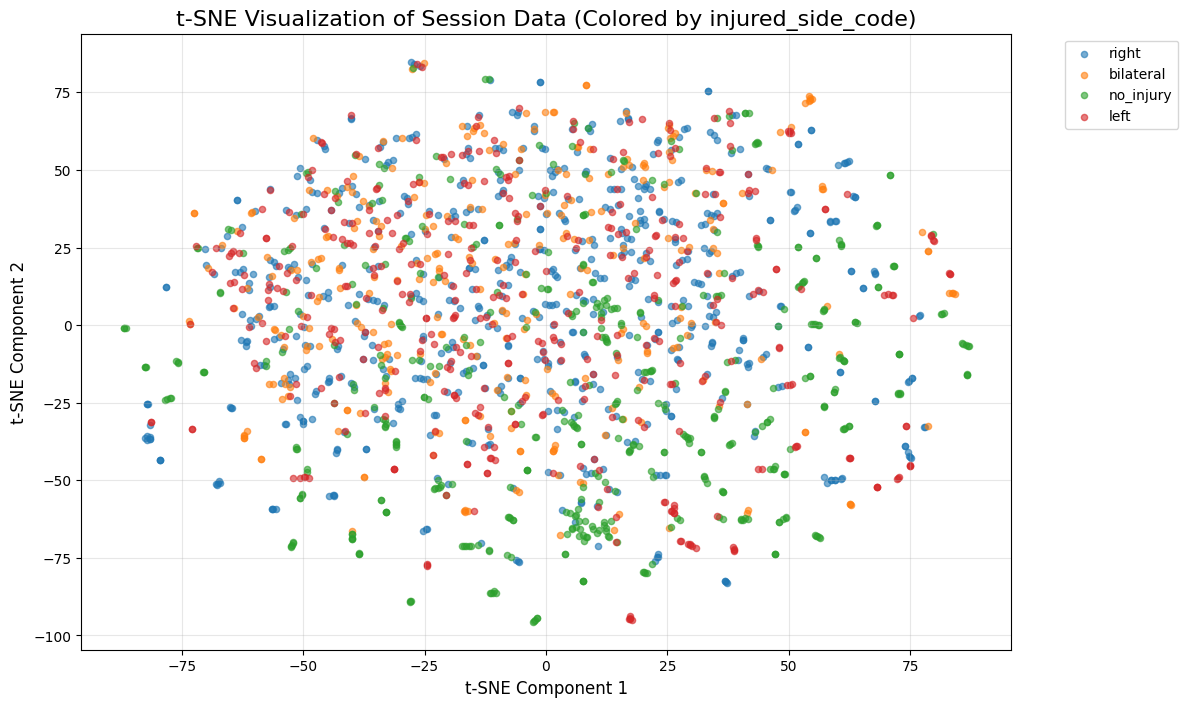

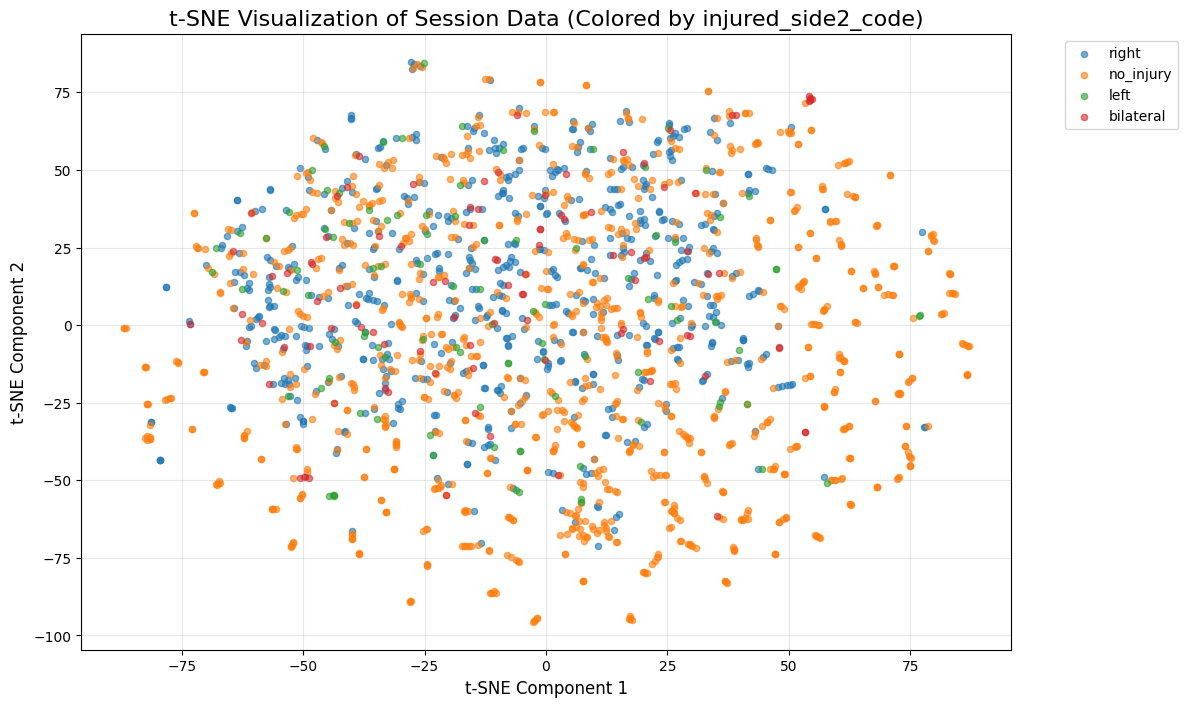

In [ ]:
def plot_model_outputs_scatter_by_column(model_output, data, column_name, model_name ,figsize=(12, 8)):
    """
    Create Model Outputs visualization colored by a specific column.
    
    Parameters:
    model_output: Model Outputs array; Expected shape (N,2)
    data: DataFrame containing the column to color by
    column_name: Name of the column to use for coloring
    model_name: Name of the model to use in the label
    figsize: Figure size tuple
    """
    plt.figure(figsize=figsize)
    
    # Get unique values in the column
    unique_values = data[column_name].dropna().unique()
    
    # Create scatter plot for each unique value
    for value in unique_values:
        mask = data[column_name] == value
        plt.scatter(model_output[mask, 0], model_output[mask, 1], alpha=0.6, s=20, label=str(value))
    
    plt.title(f'{model_name} Visualization of Session Data (Colored by {column_name})', fontsize=16)
    plt.xlabel(f'{model_name} Component 1', fontsize=12)
    plt.ylabel(f'{model_name} Component 2', fontsize=12)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, alpha=0.3)
    # plt.tight_layout()
    plt.show()

# Plot visualizations for different columns
columns_to_plot = [
    "is_injured",
    "injury_severity_code",
    "injury_name",
    "injury2_name",
    "injured_joint_code",
    "injured_joint2_code",
    "injured_side_code",
    "injured_side2_code",
]

for column in columns_to_plot:
    if column in session_data_full.columns:
        plot_model_outputs_scatter_by_column(X_tsne, session_data_full, column, "t-SNE")
    else:
        print(f"Column '{column}' not found in the dataset")


Small group of non-injured samples can be seen, also seems that if we would draw a line in the middle we would have a clasifier slightly better than choosing at random.
Other than that, not much change with previsou iteration.

Let's try with PCA

In [ ]:
# Applying PCA
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
pca.explained_variance_ratio_


array([0.09292226, 0.09153498])

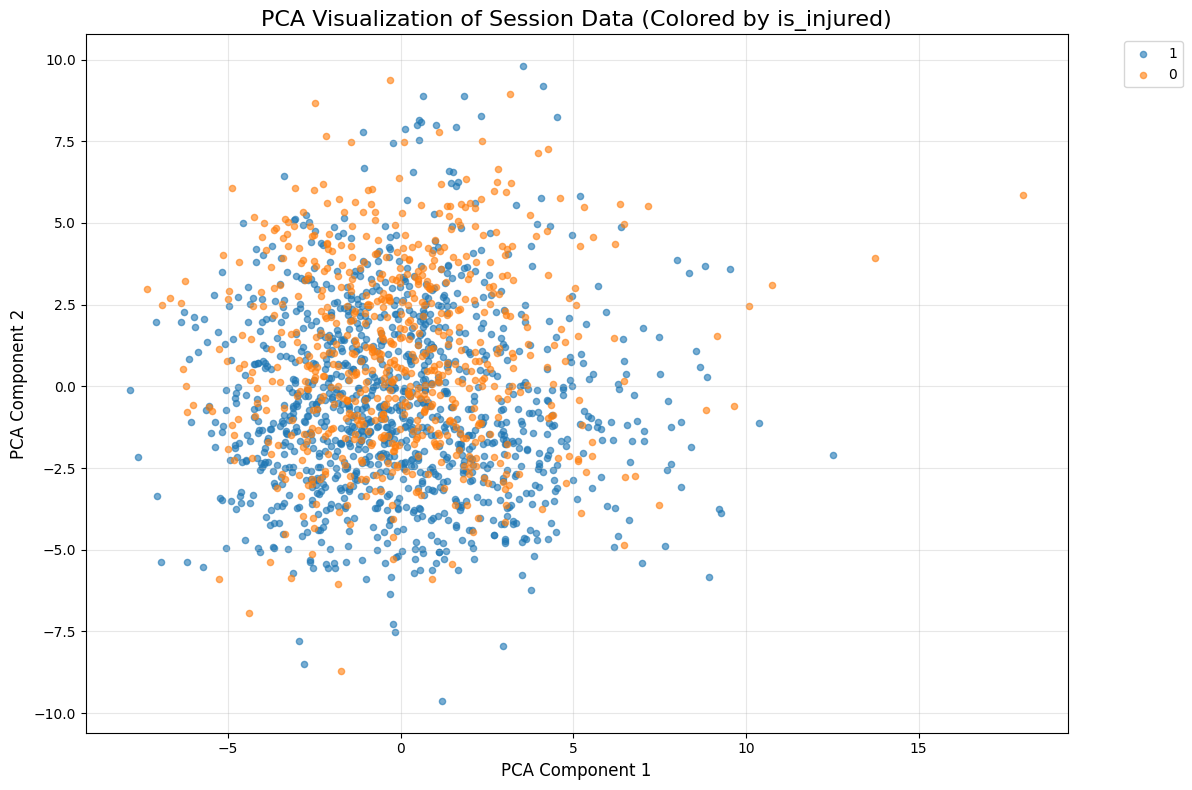

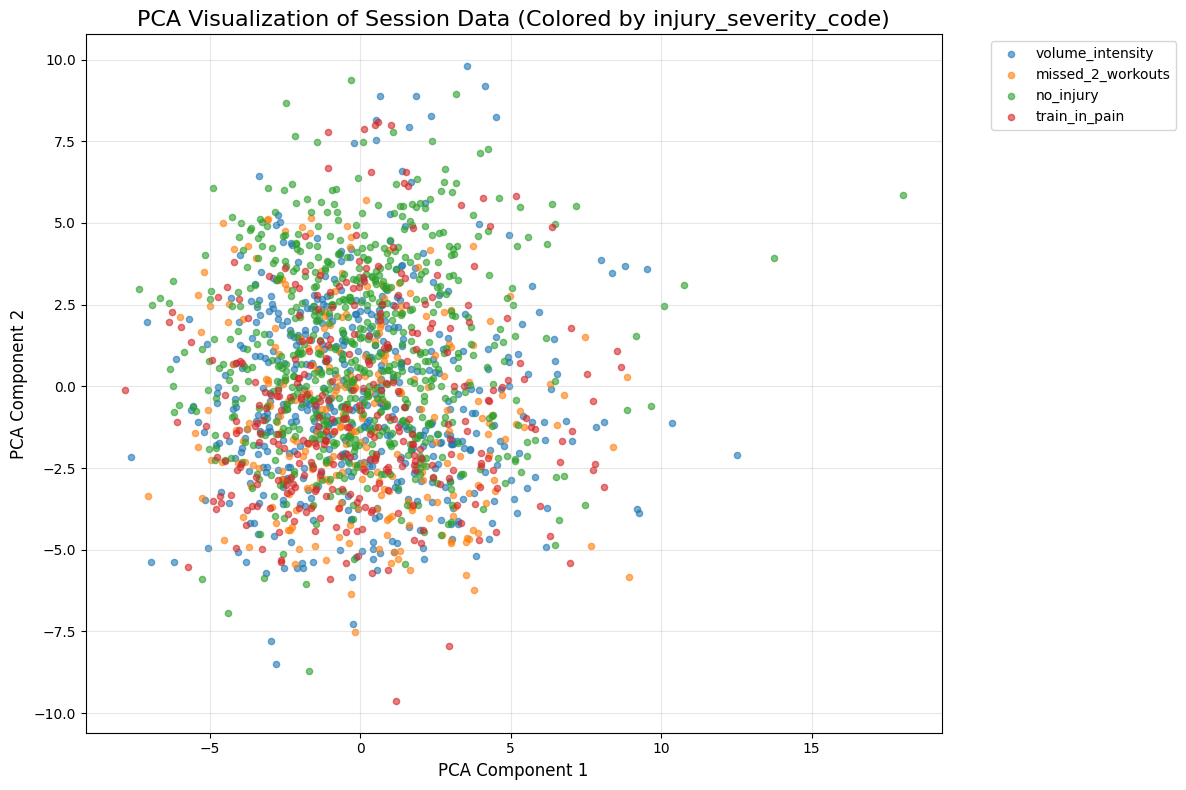

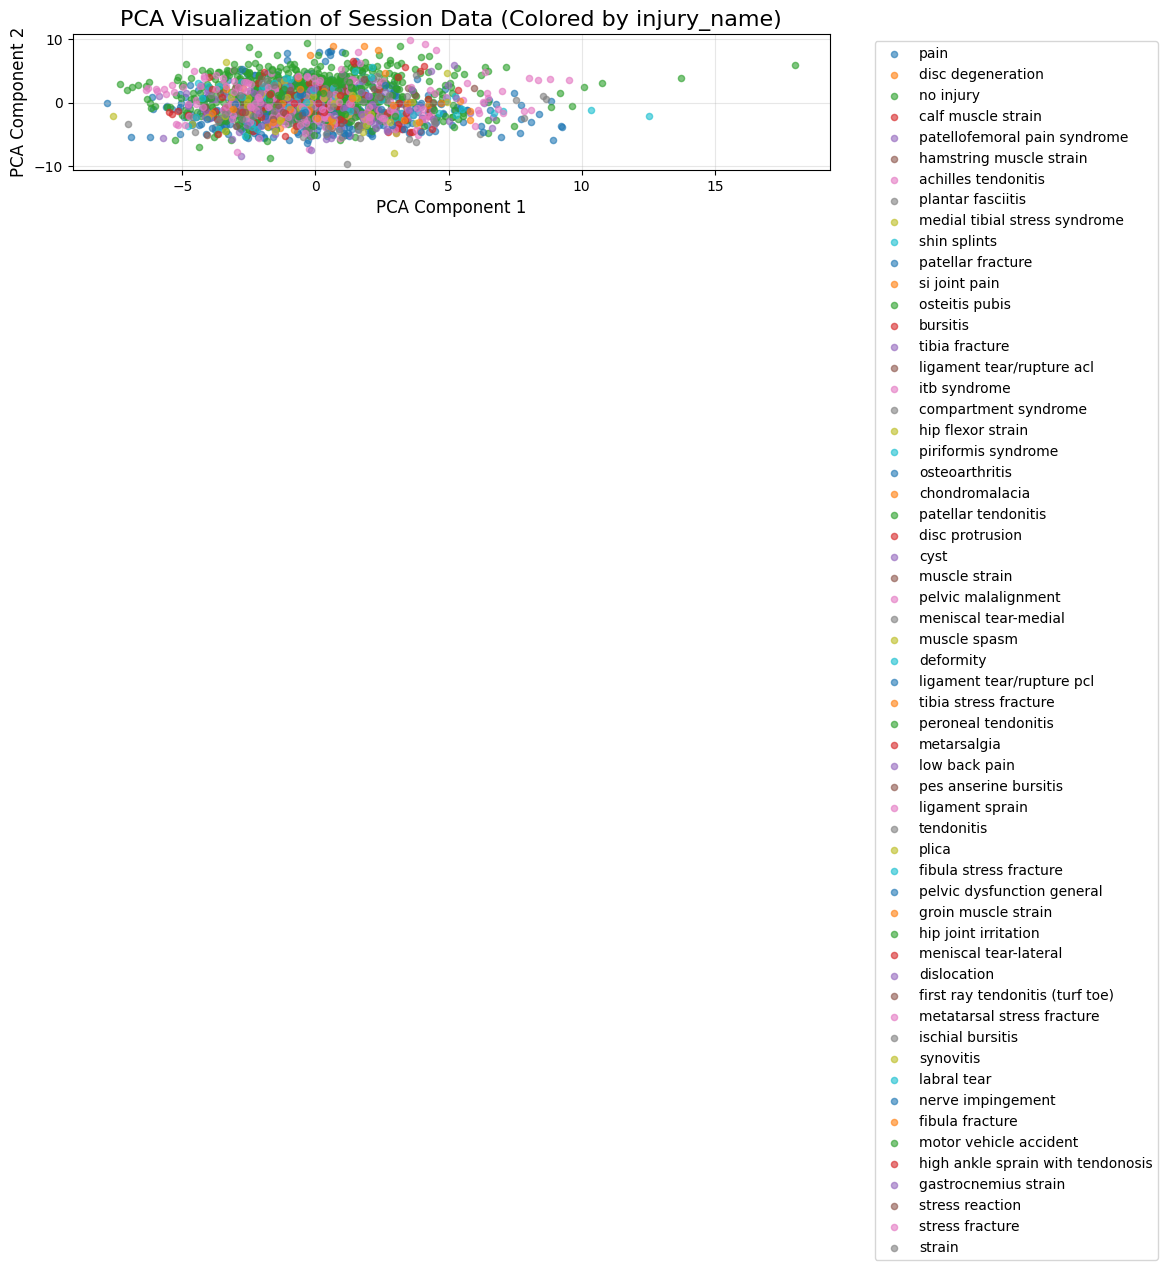

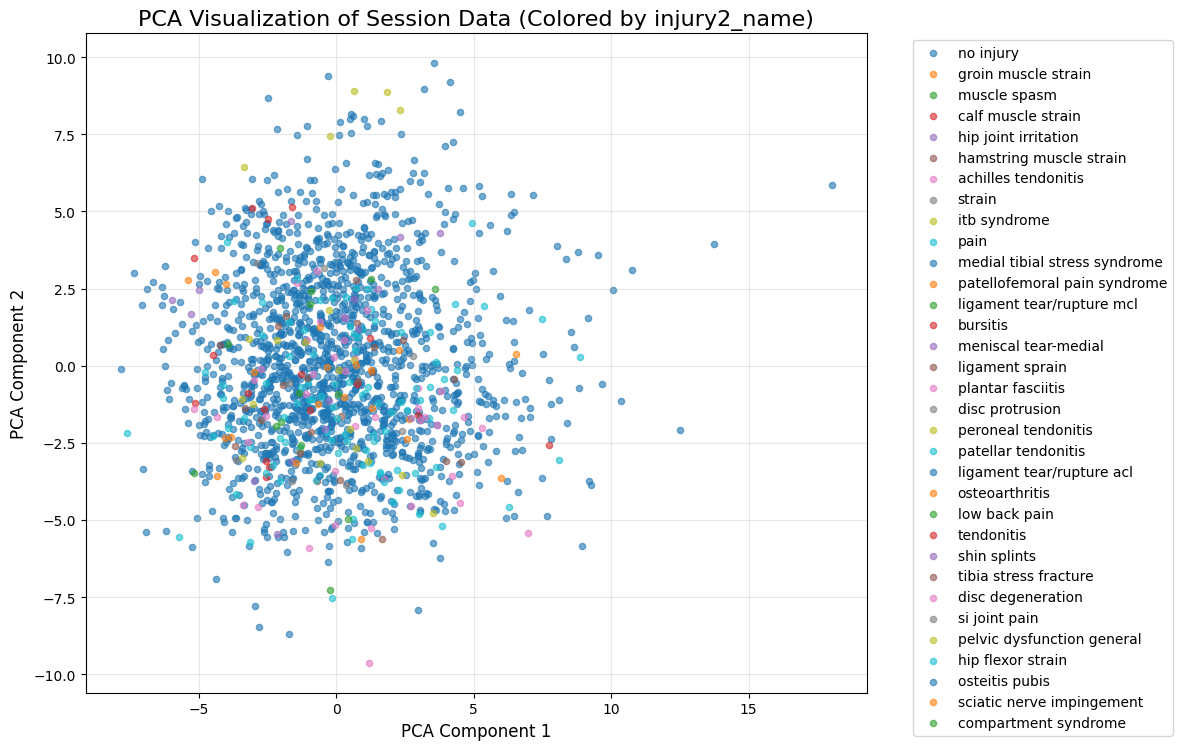

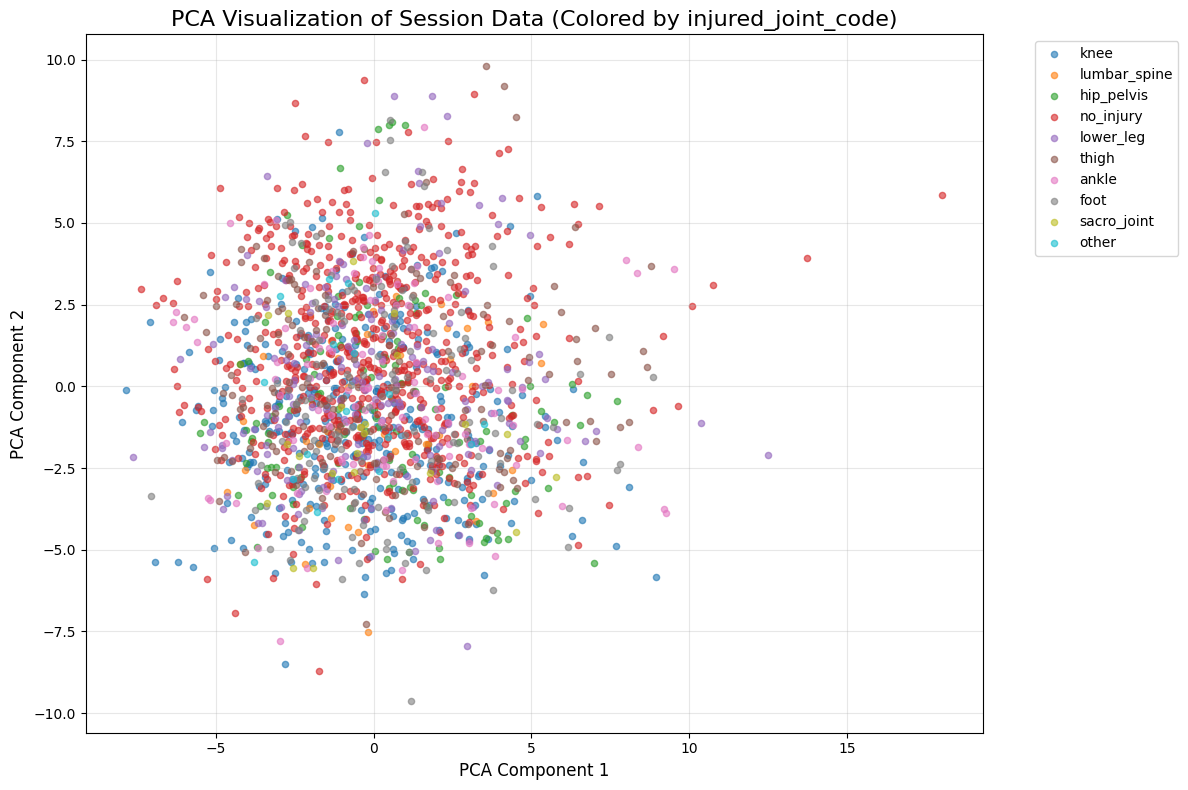

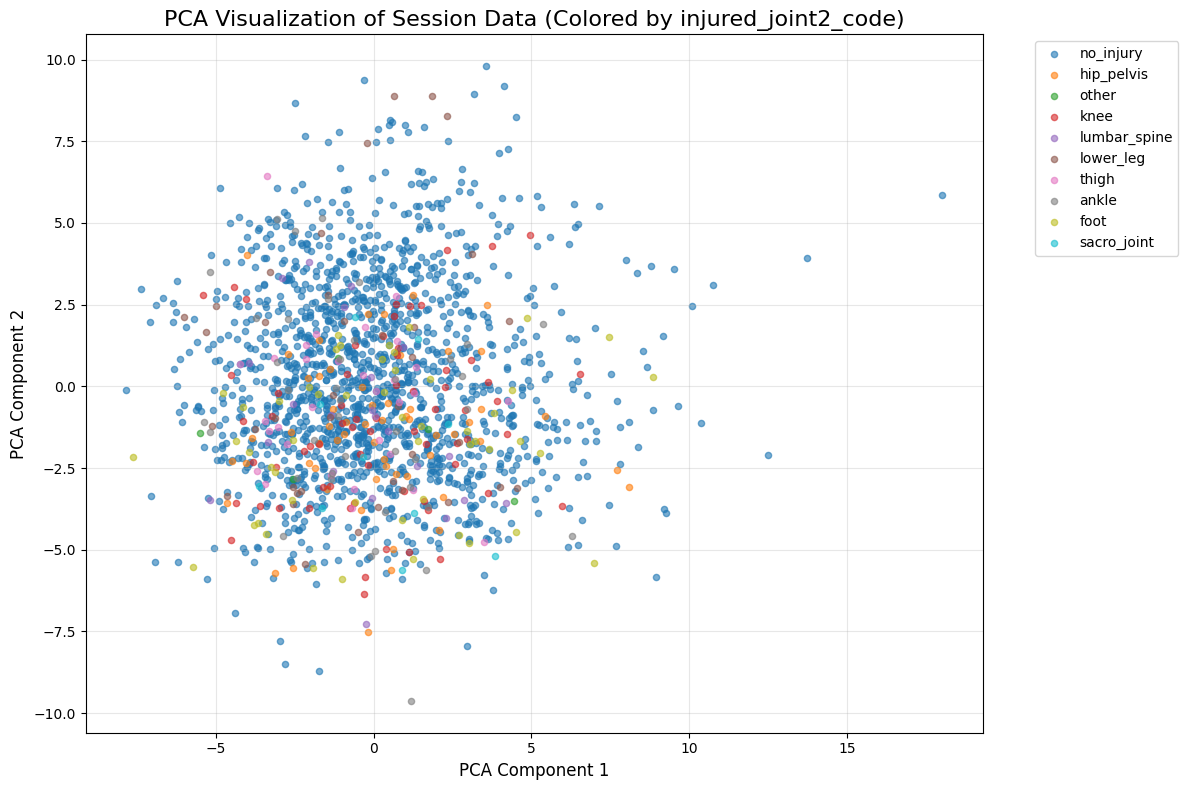

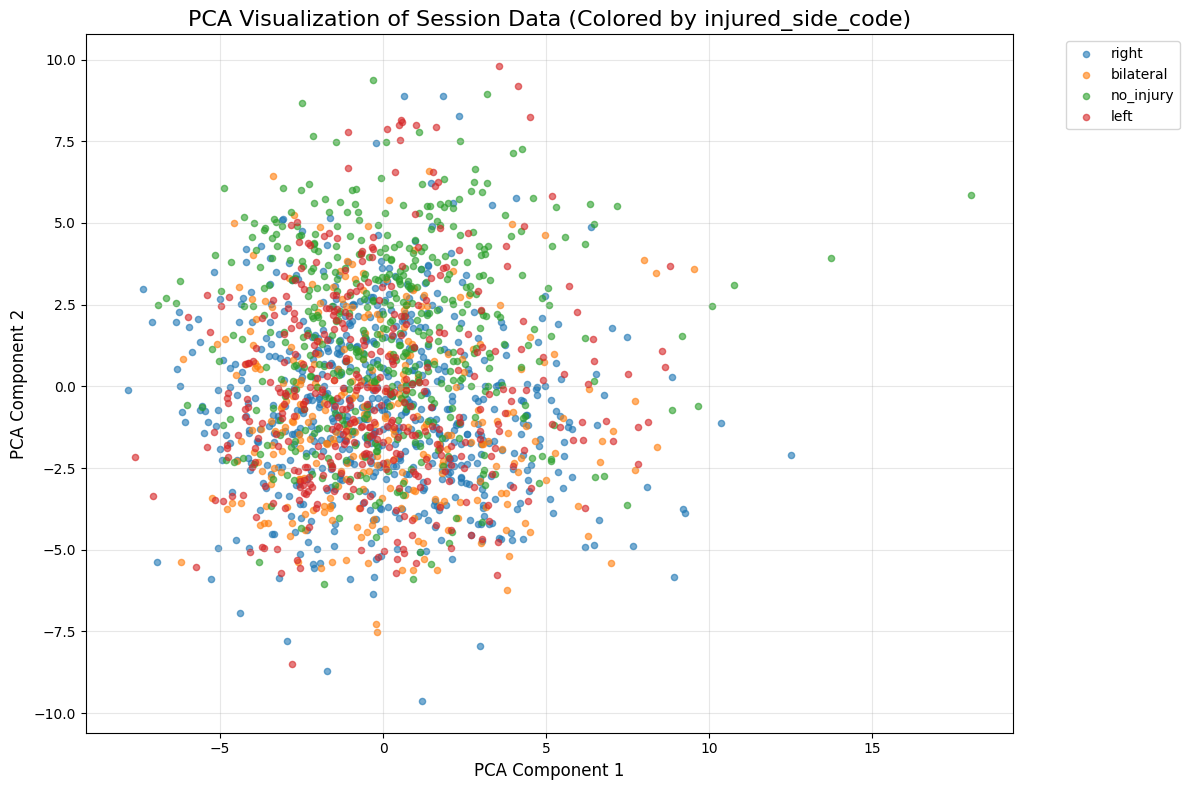

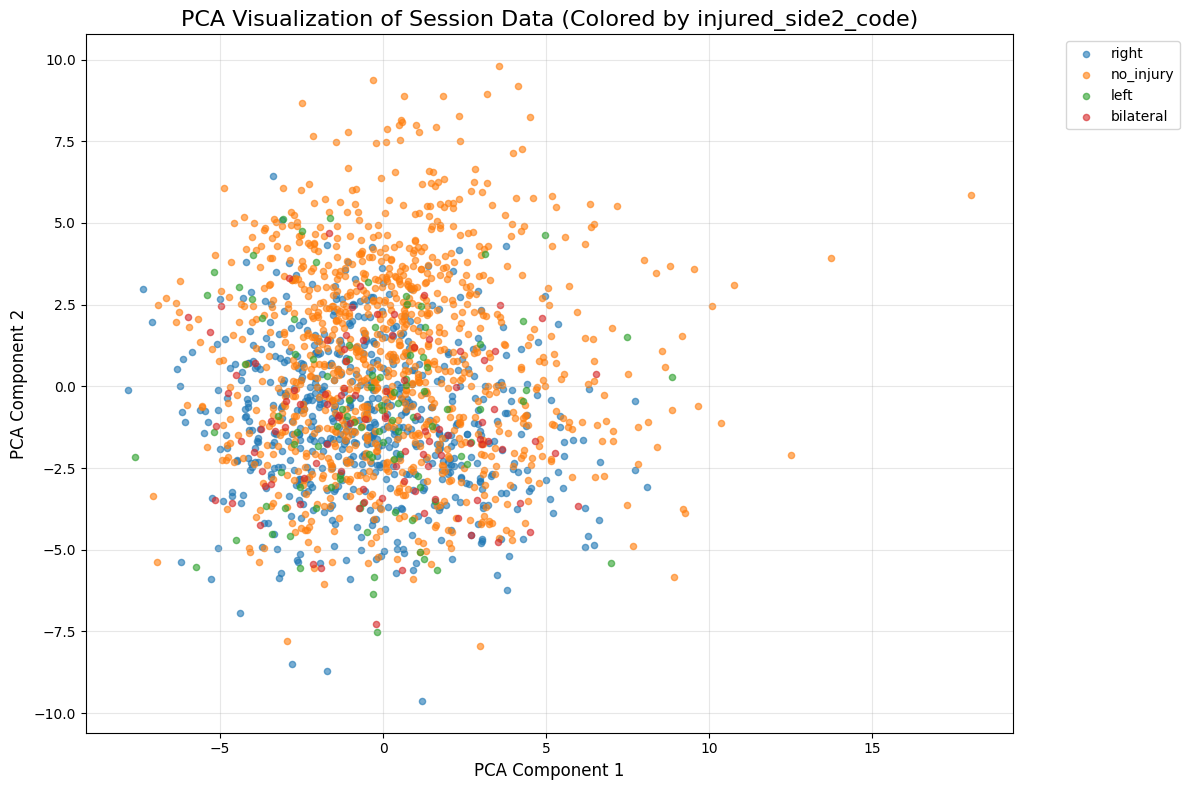

In [ ]:
# Plot visualizations for different columns
columns_to_plot = [
    "is_injured",
    "injury_severity_code",
    "injury_name",
    "injury2_name",
    "injured_joint_code",
    "injured_joint2_code",
    "injured_side_code",
    "injured_side2_code",
]

for column in columns_to_plot:
    if column in session_data_full.columns:
        plot_model_outputs_scatter_by_column(X_pca, session_data_full, column, "PCA")
    else:
        print(f"Column '{column}' not found in the dataset")

Now we are going to look at the correlation between is_injured and the rest of the variables:

Top 10 most positively correlated features with is_injured:
r_stance_time            0.222867
l_stance_time            0.218910
r_hip_ext_peak_angle     0.140189
r_ankle_eve_peak_vel     0.139564
l_ankle_eve_peak_vel     0.137646
r_foot_ang_at_hs         0.119876
l_foot_ang_at_hs         0.118026
l_hip_ext_peak_angle     0.117884
l_ankle_eve_excursion    0.109489
l_knee_rot_peak_angle    0.107530
Name: is_injured, dtype: float64

Top 10 most negatively correlated features with is_injured:
r_pelvis_drop_excursion       -0.094219
l_hip_rot_peak_angle          -0.097361
r_stride_rate                 -0.102482
l_stride_rate                 -0.102763
r_knee_abd_peak_angle         -0.111701
r_peak_pelvic_drop_velocity   -0.125055
l_ankle_df_peak_angle         -0.132278
l_stride_length               -0.165498
r_stride_length               -0.165860
speed_r                       -0.186149
Name: is_injured, dtype: float64


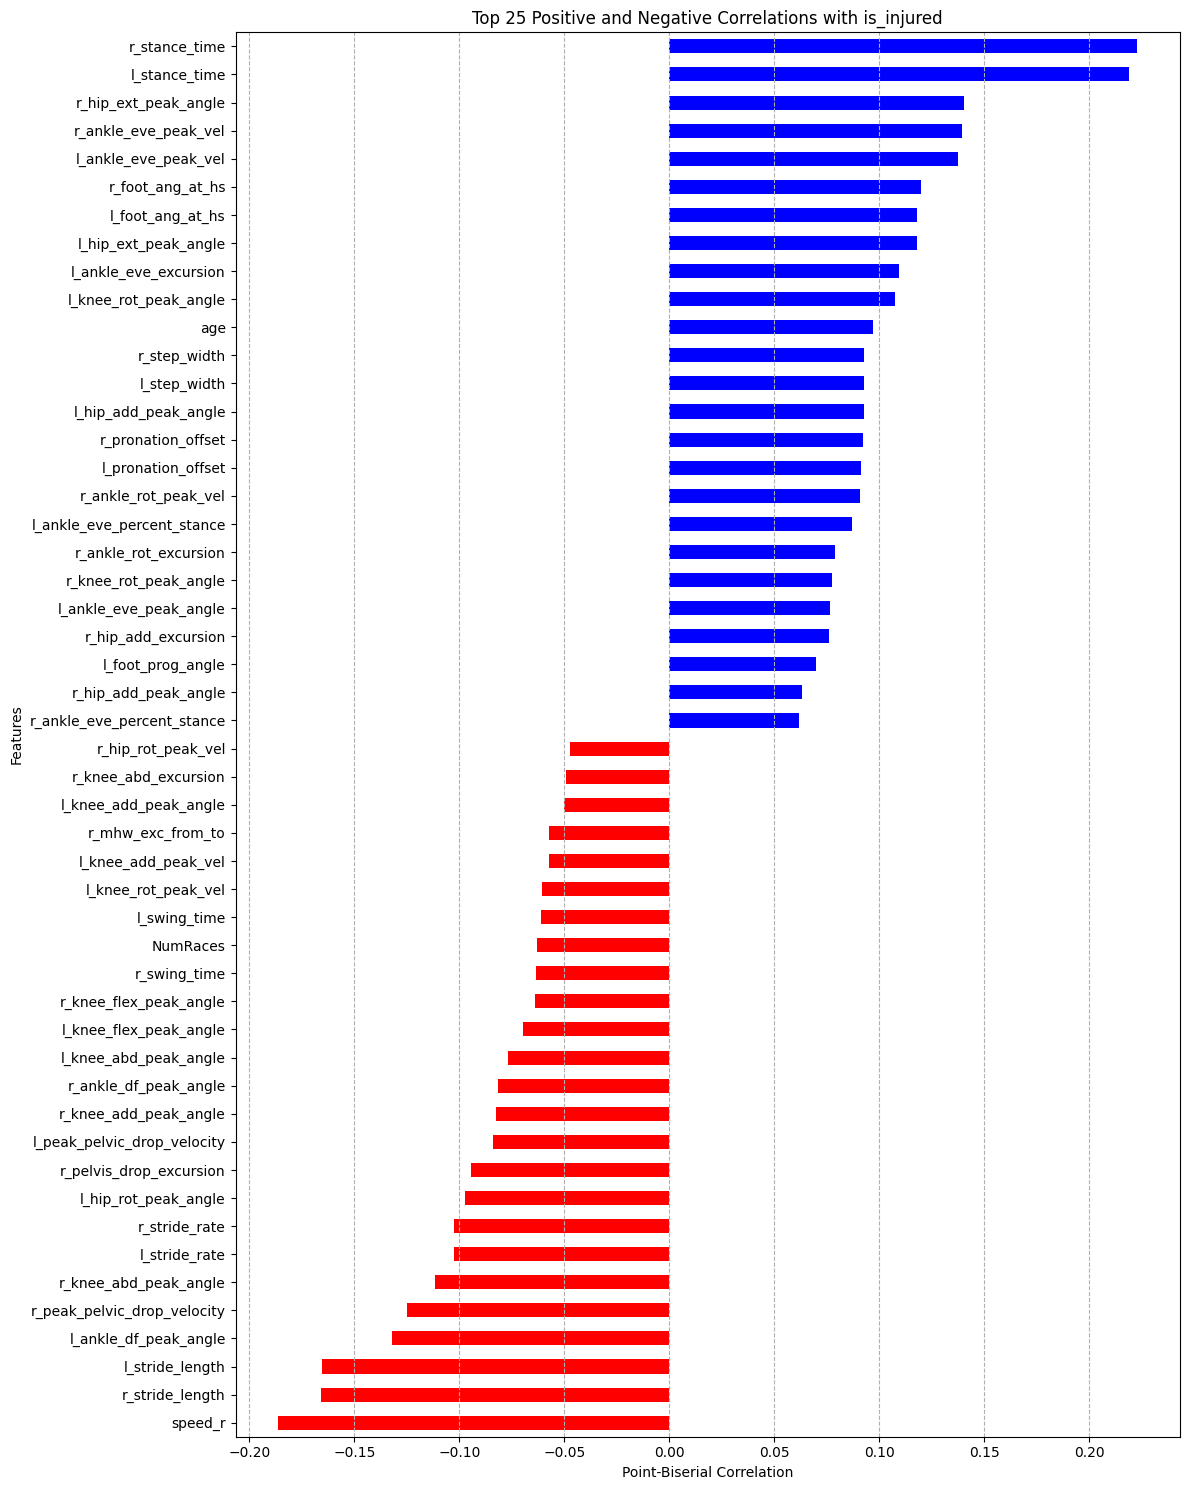

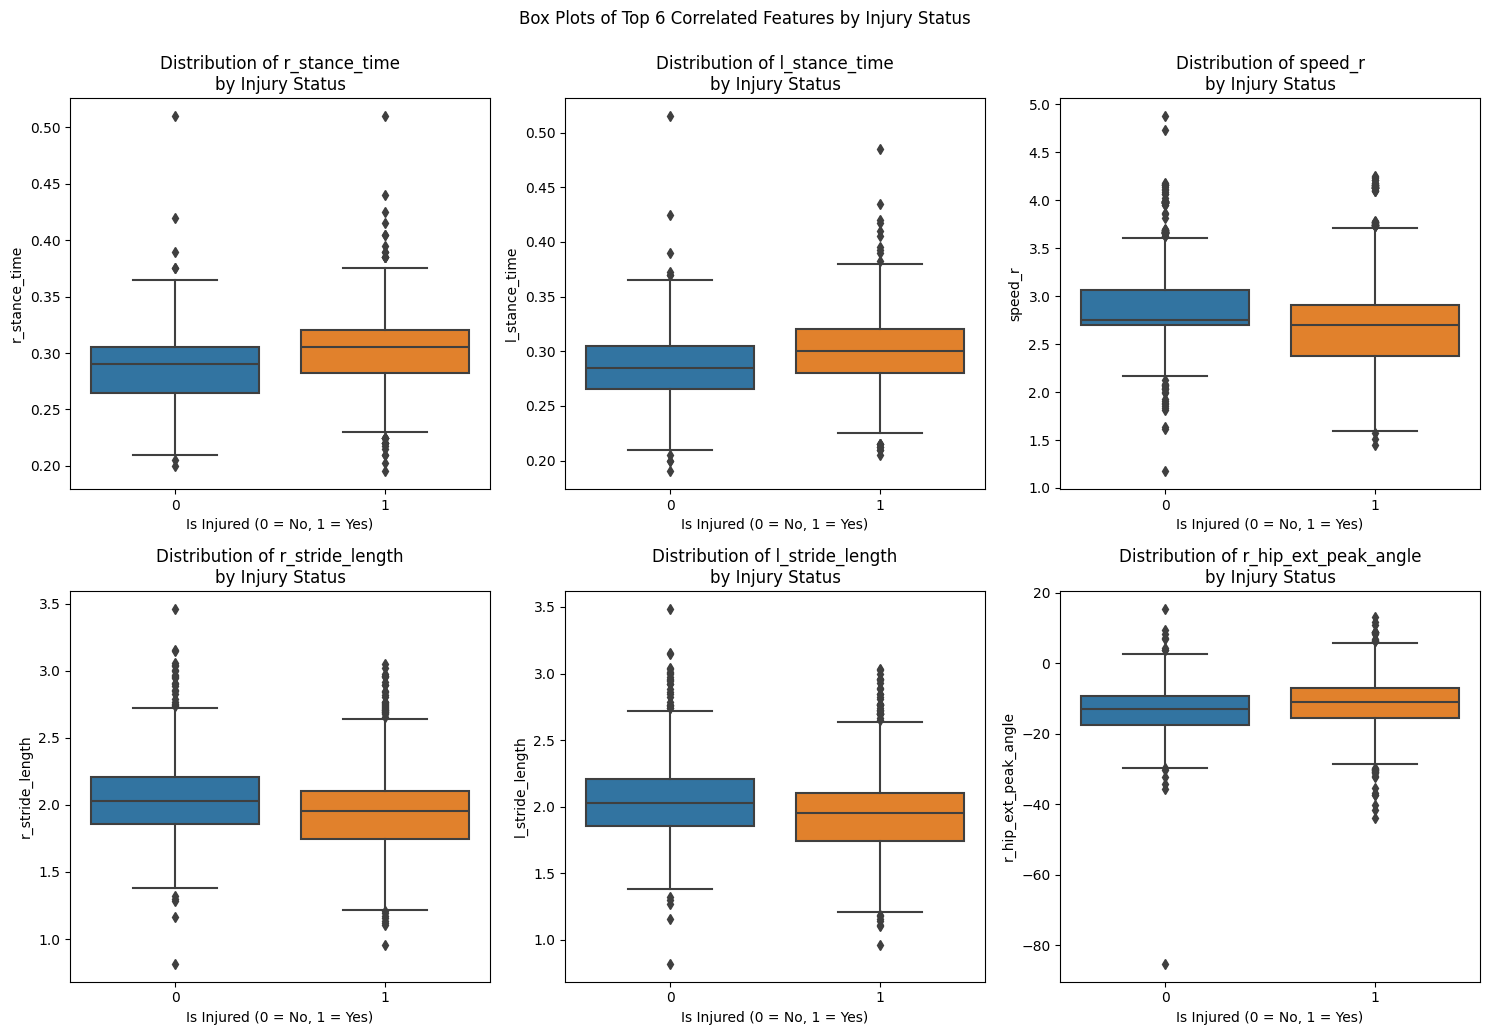

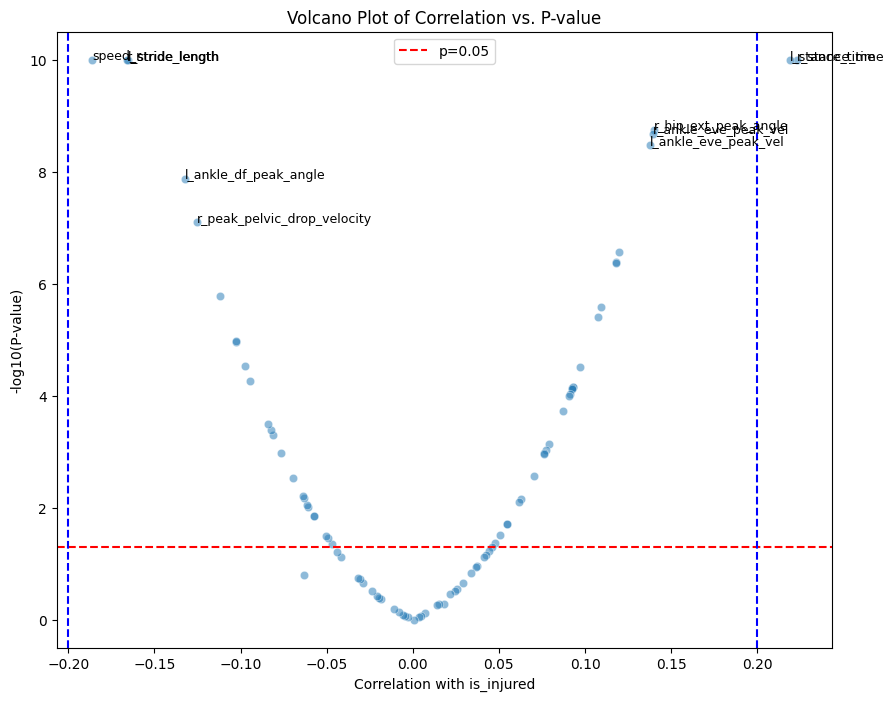


Top 15 features by Mutual Information:
Weight                    0.076500
speed_r                   0.068440
YrsRunning                0.061536
age                       0.038792
Height                    0.031932
l_knee_flex_peak_angle    0.026525
r_hip_add_peak_angle      0.024384
NumRaces                  0.022582
r_foot_ang_at_hs          0.019873
r_step_width              0.019434
l_step_width              0.019434
l_foot_prog_angle         0.018903
r_stance_time             0.018290
r_knee_add_peak_angle     0.018134
l_stride_length           0.017817
Name: MI Scores, dtype: float64


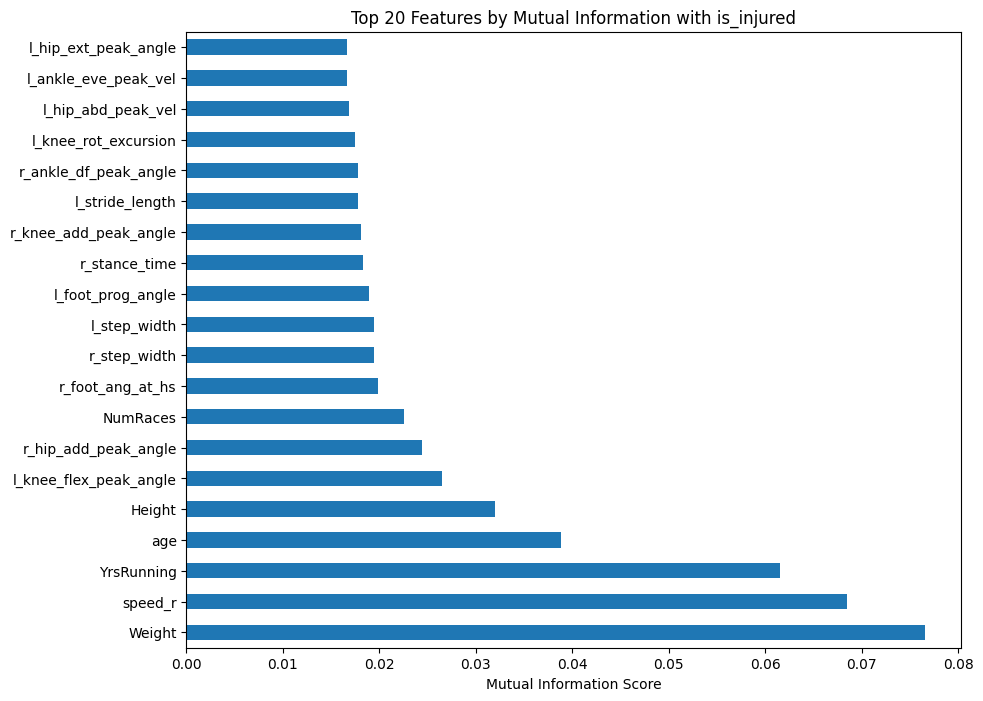


Summary of feature importance (top 20 by absolute correlation):


,Correlation,Abs_Correlation,P_Value,Mutual_Info,Corr_Rank,MI_Rank
r_stance_time,0.222867,0.222867,4.715385e-22,0.018290,1.0,13.0
l_stance_time,0.218910,0.218910,2.577794e-21,0.009608,2.0,36.0
speed_r,-0.186149,0.186149,9.558880e-16,0.068440,3.0,2.0
r_stride_length,-0.165860,0.165860,9.077124e-13,0.002723,4.0,54.0
l_stride_length,-0.165498,0.165498,1.018306e-12,0.017817,5.0,15.0
r_hip_ext_peak_angle,0.140189,0.140189,1.680416e-09,0.005681,6.0,47.0
r_ankle_eve_peak_vel,0.139564,0.139564,1.986523e-09,0.003072,7.0,53.0
l_ankle_eve_peak_vel,0.137646,0.137646,3.305597e-09,0.016680,8.0,19.0
l_ankle_df_peak_angle,-0.132278,0.132278,1.324488e-08,0.000000,9.0,71.5
r_peak_pelvic_drop_velocity,-0.125055,0.125055,7.872206e-08,0.012873,10.0,28.0


In [ ]:
# Correlation analysis between features and 'is_injured'

import pandas as pd
from scipy.stats import pointbiserialr
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import mutual_info_classif

# Ensure we are using only numerical features from X
# The 'feature_numerical_columns' variable should be available from previous cells
numerical_X = X[feature_numerical_columns].copy()

# Add 'is_injured' from Y to our numerical dataframe for correlation calculation
df_for_corr = numerical_X.copy()
df_for_corr['is_injured'] = Y['is_injured']

# --- 1. Point-biserial correlation ---
# Pandas .corr() calculates pearson correlation. When one variable is dichotomous (like is_injured)
# and the other is continuous, the pearson correlation is equivalent to the point-biserial correlation.
correlations = df_for_corr.corr(numeric_only=True)['is_injured'].dropna().sort_values(ascending=False)

# Remove the self-correlation of is_injured
correlations = correlations.drop('is_injured')

# Calculate p-values for correlations
p_values = {}
for col in numerical_X.columns:
    # pointbiserialr doesn't handle NaNs, so we drop them for the calculation
    valid_data = df_for_corr[[col, 'is_injured']].dropna()
    if valid_data.shape[0] > 1:
        corr, p = pointbiserialr(valid_data[col], valid_data['is_injured'])
        p_values[col] = p
p_values = pd.Series(p_values)


print("Top 10 most positively correlated features with is_injured:")
print(correlations.head(10))
print("\nTop 10 most negatively correlated features with is_injured:")
print(correlations.tail(10))

# --- 2. Horizontal Bar Plot of Correlations ---
top_25_corr = pd.concat([correlations.head(25), correlations.tail(25)]).sort_values()
plt.figure(figsize=(12, 15))
colors = ['red' if c < 0 else 'blue' for c in top_25_corr.values]
top_25_corr.plot(kind='barh', color=colors)
plt.title('Top 25 Positive and Negative Correlations with is_injured')
plt.xlabel('Point-Biserial Correlation')
plt.ylabel('Features')
plt.grid(axis='x', linestyle='--')
plt.tight_layout()
plt.show()

# --- 3. Box plots for top correlated features ---
top_6_features = correlations.abs().nlargest(6).index

plt.figure(figsize=(15, 10))
for i, feature in enumerate(top_6_features, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(x='is_injured', y=feature, data=df_for_corr)
    plt.title(f'Distribution of {feature}\nby Injury Status')
    plt.xlabel('Is Injured (0 = No, 1 = Yes)')
    plt.ylabel(feature)
plt.tight_layout()
plt.suptitle('Box Plots of Top 6 Correlated Features by Injury Status', y=1.03)
plt.show()

# --- 4. Volcano Plot ---
volcano_data = pd.DataFrame({'correlation': correlations, 'p_value': p_values.reindex(correlations.index)}).dropna()
volcano_data['-log10_p_value'] = -np.log10(volcano_data['p_value'] + 1e-10) # Add small constant to avoid log(0)

plt.figure(figsize=(10, 8))
sns.scatterplot(x='correlation', y='-log10_p_value', data=volcano_data, alpha=0.5)
plt.axhline(-np.log10(0.05), color='r', linestyle='--', label='p=0.05')
plt.axvline(0.2, color='b', linestyle='--')
plt.axvline(-0.2, color='b', linestyle='--')
plt.title('Volcano Plot of Correlation vs. P-value')
plt.xlabel('Correlation with is_injured')
plt.ylabel('-log10(P-value)')
plt.legend()
# Label some points
significant_features = volcano_data[volcano_data['p_value'] < 0.05].nlargest(10, '-log10_p_value')
for i, row in significant_features.iterrows():
    plt.text(row['correlation'], row['-log10_p_value'], i, fontsize=9)
plt.show()

# --- 5. Mutual Information ---
# This can capture non-linear relationships.
# We need to handle NaNs for mutual_info_classif by imputing
numerical_X_imputed = numerical_X.fillna(numerical_X.median())
mi_scores = mutual_info_classif(numerical_X_imputed, Y['is_injured'])
mi_scores = pd.Series(mi_scores, name="MI Scores", index=numerical_X_imputed.columns)
mi_scores = mi_scores.sort_values(ascending=False)

print("\nTop 15 features by Mutual Information:")
print(mi_scores.head(15))

plt.figure(figsize=(10, 8))
mi_scores.head(20).plot(kind='barh')
plt.title('Top 20 Features by Mutual Information with is_injured')
plt.xlabel('Mutual Information Score')
plt.show()

# --- 6. Summary Table ---
summary_df = pd.DataFrame({
    'Correlation': correlations,
    'Abs_Correlation': correlations.abs(),
    'P_Value': p_values,
    'Mutual_Info': mi_scores
}).sort_values('Abs_Correlation', ascending=False).dropna(subset=['Correlation', 'P_Value', 'Mutual_Info'])

summary_df['Corr_Rank'] = summary_df['Abs_Correlation'].rank(ascending=False)
summary_df['MI_Rank'] = summary_df['Mutual_Info'].rank(ascending=False)

print("\nSummary of feature importance (top 20 by absolute correlation):")
from IPython.display import display
with pd.option_context('display.max_rows', 25):
    display(summary_df.head(20))


In [ ]:
# Multicollinearity Analysis

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm
from IPython.display import display

# Use the numerical features identified previously and impute missing values
# 'feature_numerical_columns' should be available from a previous cell.
numerical_X = X[feature_numerical_columns].copy()
numerical_X_imputed = numerical_X.fillna(numerical_X.median())

# --- 1. High Correlation Pairs ---
# With many features, a full heatmap is unreadable. Instead, let's list pairs with high correlation.
print("Finding highly correlated feature pairs...")
corr_matrix = numerical_X_imputed.corr().abs()

# Select upper triangle of correlation matrix to avoid duplicate pairs
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Find pairs with correlation greater than 0.8
high_corr_pairs = upper.stack().reset_index()
high_corr_pairs.columns = ['Feature 1', 'Feature 2', 'Correlation']
high_corr_pairs = high_corr_pairs[high_corr_pairs['Correlation'] > 0.8].sort_values(by='Correlation', ascending=False)

print("\nPairs of features with absolute correlation > 0.8:")
with pd.option_context('display.max_rows', 20):
    display(high_corr_pairs)

# --- 2. Variance Inflation Factor (VIF) ---
# VIF measures how much the variance of an estimated regression coefficient is increased because of multicollinearity.
# A VIF > 10 is often considered a sign of high multicollinearity.
# Note: This can be computationally intensive for many features.

# For VIF calculation, we need to add a constant (intercept) to our data
X_for_vif = sm.add_constant(numerical_X_imputed)

print("\nCalculating VIF... (this may take a moment)")

# Calculate VIF for each feature
vif_data = pd.DataFrame()
vif_data["feature"] = X_for_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_for_vif.values, i) for i in range(len(X_for_vif.columns))]

# Remove the VIF of the constant, which is not a feature
vif_data = vif_data[vif_data['feature'] != 'const'].sort_values('VIF', ascending=False)

print("\nTop 20 Features by VIF:")
with pd.option_context('display.max_rows', 20):
    display(vif_data.head(20))

save_df_as_table_image(
    vif_data[vif_data['VIF'] > 5],
    os.path.join(c.RICKD_RESULTS_FOLDER, 'vif_session_data_full_features_gt_5.png')
)

print(f"\n{len(vif_data[vif_data['VIF'] > 10])} features have VIF > 10 (High Multicollinearity).")
print(f"{len(vif_data[(vif_data['VIF'] > 5) & (vif_data['VIF'] <= 10)])} features have VIF between 5 and 10 (Moderate Multicollinearity).")

Finding highly correlated feature pairs...

Pairs of features with absolute correlation > 0.8:


,Feature 1,Feature 2,Correlation
534,l_step_width,r_step_width,1.000000
691,l_stride_length,r_stride_length,0.999814
613,l_stride_rate,r_stride_rate,0.998800
768,l_swing_time,r_swing_time,0.937379
47,speed_r,r_stride_length,0.930643
7,speed_r,l_stride_length,0.930306
2263,l_foot_ang_at_hs,r_foot_ang_at_hs,0.908562
844,l_stance_time,r_stance_time,0.908525
1924,l_hip_ext_peak_angle,r_hip_ext_peak_angle,0.883064
2874,l_vertical_oscillation,r_vertical_oscillation,0.862028



Calculating VIF... (this may take a moment)


/Users/adrianzapaterreig/Documents/Personal/TFM/rickd-analysis/.venv/lib/python3.11/site-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)



Top 20 Features by VIF:


,feature,VIF
47,r_step_width,inf
7,l_step_width,inf
49,r_stride_length,7.706292e+04
9,l_stride_length,7.702024e+04
8,l_stride_rate,1.213412e+04
48,r_stride_rate,1.201502e+04
23,l_knee_abd_peak_angle,9.250087e+02
21,l_knee_add_peak_angle,8.193304e+02
63,r_knee_abd_peak_angle,8.123570e+02
61,r_knee_add_peak_angle,5.887614e+02



33 features have VIF > 10 (High Multicollinearity).
19 features have VIF between 5 and 10 (Moderate Multicollinearity).
